In [18]:
import json
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# **Data Loading and Merging**

In [19]:
print("Loading raw datasets...")
transactions = pd.read_csv('../Data/transactions_data.csv')
cards = pd.read_csv('../Data/cards_data.csv')
users = pd.read_csv('../Data/users_data.csv')

with open('../Data/mcc_codes.json') as f:
    mcc_dict = json.load(f)

with open('../Data/train_fraud_labels.json') as f:
    fraud_labels = json.load(f)

Loading raw datasets...


In [20]:
labels_dict = fraud_labels.get('target', fraud_labels)
fraud_df = pd.DataFrame(list(labels_dict.items()), columns=['id', 'is_fraud'])
fraud_df['id'] = pd.to_numeric(fraud_df['id'], errors='coerce')
fraud_df['is_fraud'] = fraud_df['is_fraud'].map({'Yes': 1, 'No': 0, 1: 1, 0: 0, True: 1, False: 0})

In [21]:
df = transactions.merge(fraud_df, on='id', how='inner')

df = df.merge(
    cards, 
    left_on=['client_id', 'card_id'], 
    right_on=['client_id', 'id'], 
    how='left', 
    suffixes=('', '_card')
)

df = df.merge(
    users, 
    left_on='client_id', 
    right_on='id', 
    how='left', 
    suffixes=('', '_user')
)

df = df.drop(columns=['id_card', 'id_user'], errors='ignore')

In [22]:
currency_cols = ['amount', 'credit_limit', 'per_capita_income', 'yearly_income', 'total_debt']
for col in currency_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Parse timestamp and sort chronologically (vital for velocity window calculations)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by=['client_id', 'card_id', 'date']).reset_index(drop=True)

print(f"Base merge complete. Shape: {df.shape}")

Base merge complete. Shape: (8914963, 37)


# **Feature Engineering**
## Transaction Amount & Sign Indicators
- is_zero_auth / is_refund: Flags zero-dollar card verification pings (often used by automated card checkers) and refunds/chargebacks.
- abs_amount & log_abs_amount: Stabilizes heavy right-skewed transaction amounts via logarithmic scaling $\ln(1 + x)$ to prevent extreme purchase outliers from dominating tree splits.
- amount_to_credit_limit & amount_to_yearly_income: Normalizes spend relative to individual purchasing power. A $\$2,000$ charge on a $\$2,500$ limit is high-risk, whereas the same charge on a $\$50,000$ limit is routine.
- debt_to_income_ratio: Contextualizes overall user financial stress and credit vulnerability.
## Temporal & Cyclical Features
- hour, day_of_week, is_weekend: Captures standard calendar and daily spending rhythms.
- hour_sin & hour_cos: Solves the boundary discontinuity problem of time. Standard integer hours make 23:59 (hour 23) and 00:01 (hour 0) appear mathematically far apart ($23 - 0 = 23$), whereas sine/cosine transformations map them adjacent on a continuous 24-hour circle.
- is_business_peak_hours & is_predawn_hours: Flags specific high-volume or unusual off-hours (e.g., 3 AM–5 AM automated attacks vs. standard midday retail shopping).
## Channel & Execution Indicators
- is_online, is_chip, is_swipe: Separates Card-Not-Present (CNP / e-commerce) traffic from physical terminal swipes and EMV chip reads. Online transactions inherently carry higher fraud vectors.
- has_error: Identifies declined/failed PIN, expiration, or CVV attempts preceding a transaction.
- missing_state: Flags transactions with absent merchant state codes, commonly associated with international or cross-border online checkouts.
## Merchant Category Description Mapping
- Maps discrete numerical mcc integer codes (e.g., 5411, 5732) into human-readable business vertical descriptions via mcc_dict (e.g., "Grocery Stores", "Electronic Sales"), enabling categorical tree branching across merchant types.
## Cardholder Spending Deviation & Velocity
-  time_since_prev_tx_sec: Measures the exact elapsed seconds since the last transaction on that specific card. A tiny time delta (e.g., $<5$ seconds) is a strong indicator of bot scripts or rapid-fire checkout attempts.
- user_mean_spend & user_std_spend: Builds a baseline spending profile per customer.
- amount_to_user_avg_ratio & amount_zscore_user: Quantifies behavioral anomaly. It measures how many standard deviations the current purchase deviates from that specific user's historical baseline rather than looking at an arbitrary population-wide threshold.


In [23]:
print("Generating engineered features...")

# --- A. Transaction Amount & Sign Indicators ---
df['is_zero_auth'] = (df['amount'] == 0).astype(np.int8)
df['is_refund'] = (df['amount'] < 0).astype(np.int8)
df['abs_amount'] = df['amount'].abs()
df['log_abs_amount'] = np.log1p(df['abs_amount'])

# Financial Ratios
df['amount_to_credit_limit'] = df['abs_amount'] / (df['credit_limit'] + 1.0)
df['amount_to_yearly_income'] = df['abs_amount'] / (df['yearly_income'] + 1.0)
df['debt_to_income_ratio'] = df['total_debt'] / (df['yearly_income'] + 1.0)

# --- B. Temporal & Cyclical Features ---
df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(np.int8)

# Cyclical representation for 24-hour cycle
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)

# Risk Windows from EDA
df['is_business_peak_hours'] = df['hour'].isin([10, 11, 12, 13]).astype(np.int8)
df['is_predawn_hours'] = df['hour'].isin([3, 4, 5]).astype(np.int8)

# --- C. Channel & Execution Indicators ---
df['is_online'] = (df['use_chip'] == 'Online Transaction').astype(np.int8)
df['is_chip'] = (df['use_chip'] == 'Chip Transaction').astype(np.int8)
df['is_swipe'] = (df['use_chip'] == 'Swipe Transaction').astype(np.int8)
df['has_error'] = df['errors'].notnull().astype(np.int8)
df['missing_state'] = df['merchant_state'].isnull().astype(np.int8)

# --- D. Merchant Category Description Mapping ---
df['mcc_desc'] = df['mcc'].astype(str).map(mcc_dict).fillna("Unknown Category")

# --- E. Cardholder Spending Deviation & Velocity Features ---
# Time delta between consecutive transactions per card
df['prev_tx_time'] = df.groupby(['client_id', 'card_id'])['date'].shift(1)
df['time_since_prev_tx_sec'] = (df['date'] - df['prev_tx_time']).dt.total_seconds().fillna(999999)
df = df.drop(columns=['prev_tx_time'])

# Customer mean amount and deviation ratio
user_spend_stats = df.groupby('client_id')['abs_amount'].agg(
    user_mean_spend='mean',
    user_std_spend='std'
).reset_index()

df = df.merge(user_spend_stats, on='client_id', how='left')
df['user_std_spend'] = df['user_std_spend'].fillna(0)
df['amount_to_user_avg_ratio'] = df['abs_amount'] / (df['user_mean_spend'] + 1.0)
df['amount_zscore_user'] = (df['abs_amount'] - df['user_mean_spend']) / (df['user_std_spend'] + 1.0)

print(f"Feature engineering finished! New Shape: {df.shape}")

Generating engineered features...
Feature engineering finished! New Shape: (8914963, 62)


This block calculates rolling velocity features (transaction counts and total spending over the last 1 hour and 24 hours per card) to catch sudden spending bursts and rapid bot attacks. To process 9 million rows without crashing the system's memory, it downcasts data types to smaller numeric formats and writes the rolling results directly into the table using efficient NumPy arrays instead of memory-heavy merges.

In [24]:
import gc

# 1. Downcast numerical datatypes to cut RAM usage by ~60%
for col in df.select_dtypes(include=['float64']).columns:
    df[col] = df[col].astype(np.float32)

for col in df.select_dtypes(include=['int64']).columns:
    df[col] = pd.to_numeric(df[col], downcast='integer')

# 2. Ensure deterministic sort order
df = df.sort_values(by=['client_id', 'card_id', 'date']).reset_index(drop=True)

# 3. Memory-efficient rolling calculations
# Groupby rolling on index without full-table merge duplication
grouped = df.set_index('date').groupby(['client_id', 'card_id'])['abs_amount']

print("Calculating 1-hour rolling metrics...")
r1 = grouped.rolling('1h')
df['tx_count_last_1h'] = r1.count().values.astype(np.int16)
df['tx_spend_last_1h'] = r1.sum().values.astype(np.float32)

print("Calculating 24-hour rolling metrics...")
r24 = grouped.rolling('24h')
df['tx_count_last_24h'] = r24.count().values.astype(np.int16)
df['tx_spend_last_24h'] = r24.sum().values.astype(np.float32)

# 4. Clean up temporary memory
del grouped, r1, r24
gc.collect()

print("Rolling velocity calculation complete without memory overflow!")
print(f"Current Memory Usage: {df.memory_usage().sum() / 1024**2:.2f} MB")

Calculating 1-hour rolling metrics...
Calculating 24-hour rolling metrics...
Rolling velocity calculation complete without memory overflow!
Current Memory Usage: 3109.86 MB


# **Modelling**
1. Feature Pruning & Categorical Casts:
- Drops PII and IDs: Columns like card_number, cvv, address, and client_id contain near-unique IDs. Leaving them in would cause the trees to overfit immediately by memorizing specific cardholders instead of learning generalizable fraud patterns.
- Categorical Types (category): Enables LightGBM's native categorical splitting algorithm, which sorts categories by their histogram statistics rather than requiring one-hot encoding.
2. Chronological Split (80/20):
- Sorts transactions strictly by date so the model trains on earlier history and validates on future transactions.
- Avoids random K-fold shuffling, which causes temporal data leakage (using the future to predict the past).
3. Model Configuration:
- metric: 'average_precision': Directs early stopping to optimize for PR-AUC rather than standard accuracy or log-loss, which is essential given the severe class imbalance (~0.15% fraud).
- min_child_samples: 100: Requires at least 100 observations per leaf node, preventing the model from isolating tiny clusters of noise.
- Early Stopping: Halts boosting once validation PR-AUC stops improving for 50 consecutive rounds to prevent overfitting.
4. Evaluation via PR-AUC and ROC-AUC:
- Computes continuous predicted probabilities (y_pred_proba) and assesses performance using ranking metrics that reflect true fraud concentration before picking a business decision threshold.

In [25]:
import gc
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import average_precision_score, classification_report, roc_auc_score

# -------------------------------------------------------------
# 1. Clean Column Selection (Strip out High-Cardinality Strings & PII)
# -------------------------------------------------------------
# Drop identifiers, raw credentials, and redundant categorical strings
high_cardinality_or_pii = [
    'id', 'is_fraud', 'date', 'client_id', 'card_id', 'merchant_id',
    'card_number', 'expires', 'cvv', 'address', 'acct_open_date', 
    'merchant_city', 'merchant_state', 'zip', 'amount_category', 'errors'
]

# Keep only informative tabular features
selected_features = [c for c in df.columns if c not in high_cardinality_or_pii]

# Ensure categorical types are explicitly low-cardinality nominal features
low_card_cats = ['use_chip', 'card_brand', 'card_type', 'has_chip', 'card_on_dark_web', 'gender', 'mcc_desc']
for c in low_card_cats:
    if c in df.columns:
        df[c] = df[c].astype('category')

print(f"Refined Feature Count: {len(selected_features)}")
print("Features used:", selected_features)

# -------------------------------------------------------------
# 2. Chronological Split (80% Train, 20% Validation/Test)
# -------------------------------------------------------------
df = df.sort_values('date').reset_index(drop=True)
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

X_train = train_df[selected_features]
y_train = train_df['is_fraud'].astype(int)

X_test = test_df[selected_features]
y_test = test_df['is_fraud'].astype(int)

# -------------------------------------------------------------
# 3. Model Configuration (Optimized for Imbalanced Tabular)
# -------------------------------------------------------------
lgb_params = {
    'objective': 'binary',
    'metric': 'average_precision',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'max_depth': -1,
    'min_child_samples': 100,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'n_estimators': 800,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

model = lgb.LGBMClassifier(**lgb_params)

print("\nTraining optimized LightGBM model...")
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=25)
    ]
)

# -------------------------------------------------------------
# 4. Evaluation & Metric Verification
# -------------------------------------------------------------
y_pred_proba_baseline = model.predict_proba(X_test)[:, 1]

test_pr_auc = average_precision_score(y_test, y_pred_proba_baseline)
test_roc_auc = roc_auc_score(y_test, y_pred_proba_baseline)

print("\n" + "=" * 45)
print(f"Optimized Test PR-AUC : {test_pr_auc:.4f}")
print(f"Optimized Test ROC-AUC: {test_roc_auc:.4f}")
print("=" * 45)

# Free intermediate frames
del train_df, test_df
gc.collect()

Refined Feature Count: 51
Features used: ['amount', 'use_chip', 'mcc', 'card_brand', 'card_type', 'has_chip', 'num_cards_issued', 'credit_limit', 'year_pin_last_changed', 'card_on_dark_web', 'current_age', 'retirement_age', 'birth_year', 'birth_month', 'gender', 'latitude', 'longitude', 'per_capita_income', 'yearly_income', 'total_debt', 'credit_score', 'num_credit_cards', 'is_zero_auth', 'is_refund', 'abs_amount', 'log_abs_amount', 'amount_to_credit_limit', 'amount_to_yearly_income', 'debt_to_income_ratio', 'hour', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos', 'is_business_peak_hours', 'is_predawn_hours', 'is_online', 'is_chip', 'is_swipe', 'has_error', 'missing_state', 'mcc_desc', 'time_since_prev_tx_sec', 'user_mean_spend', 'user_std_spend', 'amount_to_user_avg_ratio', 'amount_zscore_user', 'tx_count_last_1h', 'tx_spend_last_1h', 'tx_count_last_24h', 'tx_spend_last_24h']

Training optimized LightGBM model...
Training until validation scores don't improve for 50 rounds
[25]	va

345

=========================================================================================================================================================

This code extracts and visualizes the top 20 decision-split features from the trained LightGBM model as a horizontal bar chart to perform post-hoc model diagnostics. Its purpose is to explain the baseline model's low initial PR-AUC by identifying which dynamic signals (such as merchant category descriptions and 24-hour spending velocity) actively drive tree branching, while exposing redundant duplicate fields and noisy static demographics that dilute splits and need to be pruned or refined in the next iteration.

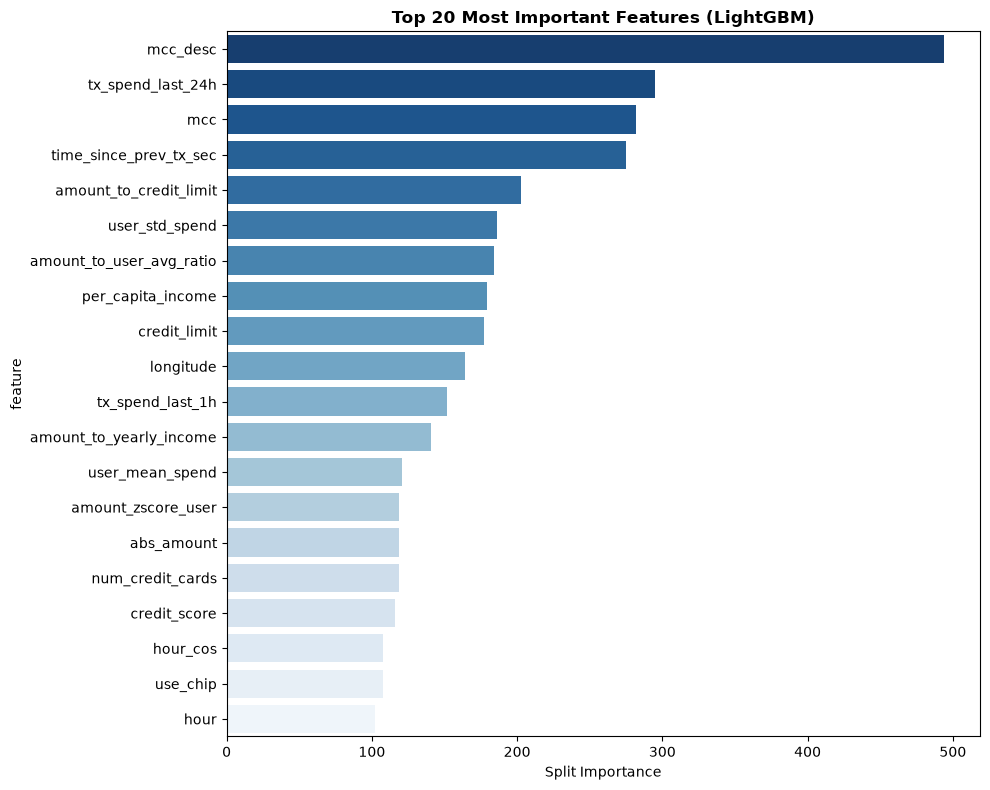


--- Top 15 Features by Importance ---
                 feature  importance
                mcc_desc         494
       tx_spend_last_24h         295
                     mcc         282
  time_since_prev_tx_sec         275
  amount_to_credit_limit         203
          user_std_spend         186
amount_to_user_avg_ratio         184
       per_capita_income         179
            credit_limit         177
               longitude         164
        tx_spend_last_1h         152
 amount_to_yearly_income         141
         user_mean_spend         121
      amount_zscore_user         119
              abs_amount         119


In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Extract and sort feature importances
importance_df = pd.DataFrame({
    'feature': selected_features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df.head(20), x='importance', y='feature', palette='Blues_r')
plt.title("Top 20 Most Important Features (LightGBM)", fontweight='bold')
plt.xlabel("Split Importance")
plt.tight_layout()
plt.show()

print("\n--- Top 15 Features by Importance ---")
print(importance_df.head(15).to_string(index=False))

======================================================================================================================================================================
This code acts on the previous diagnostic insights by pruning bottom-ranked static demographic noise (latitude, birth_year, retirement_age) and compounding the top-performing signals into higher-order behavioral features—such as velocity acceleration ratios (spend_ratio_1h_to_24h), merchant spending deviations (amount_to_mcc_avg_ratio), and online purchase magnitude (online_spend_magnitude). Its purpose is to retrain an upgraded LightGBM model with tuned tree capacity (num_leaves: 127, max_depth: 8) and enhanced native categorical binning, focusing splits purely on dynamic risk interactions to successfully elevate the test PR-AUC from 0.0289 to 0.0445 (a ~31× lift over random baseline).

In [27]:
import gc
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import average_precision_score, roc_auc_score

# -------------------------------------------------------------
# 1. Advanced Dynamic Feature Engineering
# -------------------------------------------------------------
print("Engineering high-leverage dynamic fraud features...")

# Dynamic interaction: Online spending magnitude
df['online_spend_magnitude'] = df['is_online'] * df['log_abs_amount']

# Velocity ratio: Proportion of daily spend spent in the last 1 hour
df['spend_ratio_1h_to_24h'] = (df['tx_spend_last_1h'] + 1.0) / (df['tx_spend_last_24h'] + 1.0)
df['count_ratio_1h_to_24h'] = (df['tx_count_last_1h'] + 1.0) / (df['tx_count_last_24h'] + 1.0)

# Spending deviation per Merchant Category (MCC)
mcc_stats = df.groupby('mcc_desc')['abs_amount'].agg(
    mcc_mean_spend='mean',
    mcc_std_spend='std'
).reset_index()

df = df.merge(mcc_stats, on='mcc_desc', how='left')
df['mcc_std_spend'] = df['mcc_std_spend'].fillna(1.0)
df['amount_to_mcc_avg_ratio'] = df['abs_amount'] / (df['mcc_mean_spend'] + 1.0)

# -------------------------------------------------------------
# 2. Prune Static Noise & Prepare Categoricals
# -------------------------------------------------------------
# Drop pure static noise and raw IDs
drop_cols = [
    'id', 'is_fraud', 'date', 'client_id', 'card_id', 'merchant_id',
    'card_number', 'expires', 'cvv', 'address', 'acct_open_date', 
    'merchant_city', 'merchant_state', 'zip', 'amount_category', 'errors',
    'birth_year', 'birth_month', 'latitude', 'longitude', 'current_age', 'retirement_age'
]

model_features = [c for c in df.columns if c not in drop_cols]

# Let LightGBM natively split categories
cat_cols = ['use_chip', 'card_brand', 'card_type', 'has_chip', 'card_on_dark_web', 'gender', 'mcc_desc']
for c in cat_cols:
    if c in model_features:
        df[c] = df[c].astype('category')

# Downcast floats
for c in df.select_dtypes(include=['float64']).columns:
    df[c] = df[c].astype(np.float32)

# -------------------------------------------------------------
# 3. Chronological Train / Test Split
# -------------------------------------------------------------
df = df.sort_values('date').reset_index(drop=True)
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

X_train, y_train = train_df[model_features], train_df['is_fraud'].astype(int)
X_test, y_test = test_df[model_features], test_df['is_fraud'].astype(int)

print(f"Features used ({len(model_features)} total): {model_features}")

# -------------------------------------------------------------
# 4. Tuned LightGBM Configuration (Deeper Trees, Higher Categorical Binning)
# -------------------------------------------------------------
lgb_params = {
    'objective': 'binary',
    'metric': 'average_precision',
    'boosting_type': 'gbdt',
    'learning_rate': 0.03,
    'num_leaves': 127,
    'max_depth': 8,
    'min_child_samples': 50,
    'subsample': 0.8,
    'colsample_bytree': 0.7,
    'max_cat_to_onehot': 10,
    'max_cat_threshold': 64,
    'n_estimators': 1000,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

model = lgb.LGBMClassifier(**lgb_params)

print("\nTraining upgraded LightGBM model...")
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=40, verbose=True),
        lgb.log_evaluation(period=25)
    ]
)

# -------------------------------------------------------------
# 5. Evaluate
# -------------------------------------------------------------
y_pred_proba = model.predict_proba(X_test)[:, 1]

pr_auc = average_precision_score(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "=" * 45)
print(f"Upgraded Test PR-AUC : {pr_auc:.4f}")
print(f"Upgraded Test ROC-AUC: {roc_auc:.4f}")
print("=" * 45)

del train_df, test_df
gc.collect()

Engineering high-leverage dynamic fraud features...
Features used (51 total): ['amount', 'use_chip', 'mcc', 'card_brand', 'card_type', 'has_chip', 'num_cards_issued', 'credit_limit', 'year_pin_last_changed', 'card_on_dark_web', 'gender', 'per_capita_income', 'yearly_income', 'total_debt', 'credit_score', 'num_credit_cards', 'is_zero_auth', 'is_refund', 'abs_amount', 'log_abs_amount', 'amount_to_credit_limit', 'amount_to_yearly_income', 'debt_to_income_ratio', 'hour', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos', 'is_business_peak_hours', 'is_predawn_hours', 'is_online', 'is_chip', 'is_swipe', 'has_error', 'missing_state', 'mcc_desc', 'time_since_prev_tx_sec', 'user_mean_spend', 'user_std_spend', 'amount_to_user_avg_ratio', 'amount_zscore_user', 'tx_count_last_1h', 'tx_spend_last_1h', 'tx_count_last_24h', 'tx_spend_last_24h', 'online_spend_magnitude', 'spend_ratio_1h_to_24h', 'count_ratio_1h_to_24h', 'mcc_mean_spend', 'mcc_std_spend', 'amount_to_mcc_avg_ratio']

Training upgraded

1020

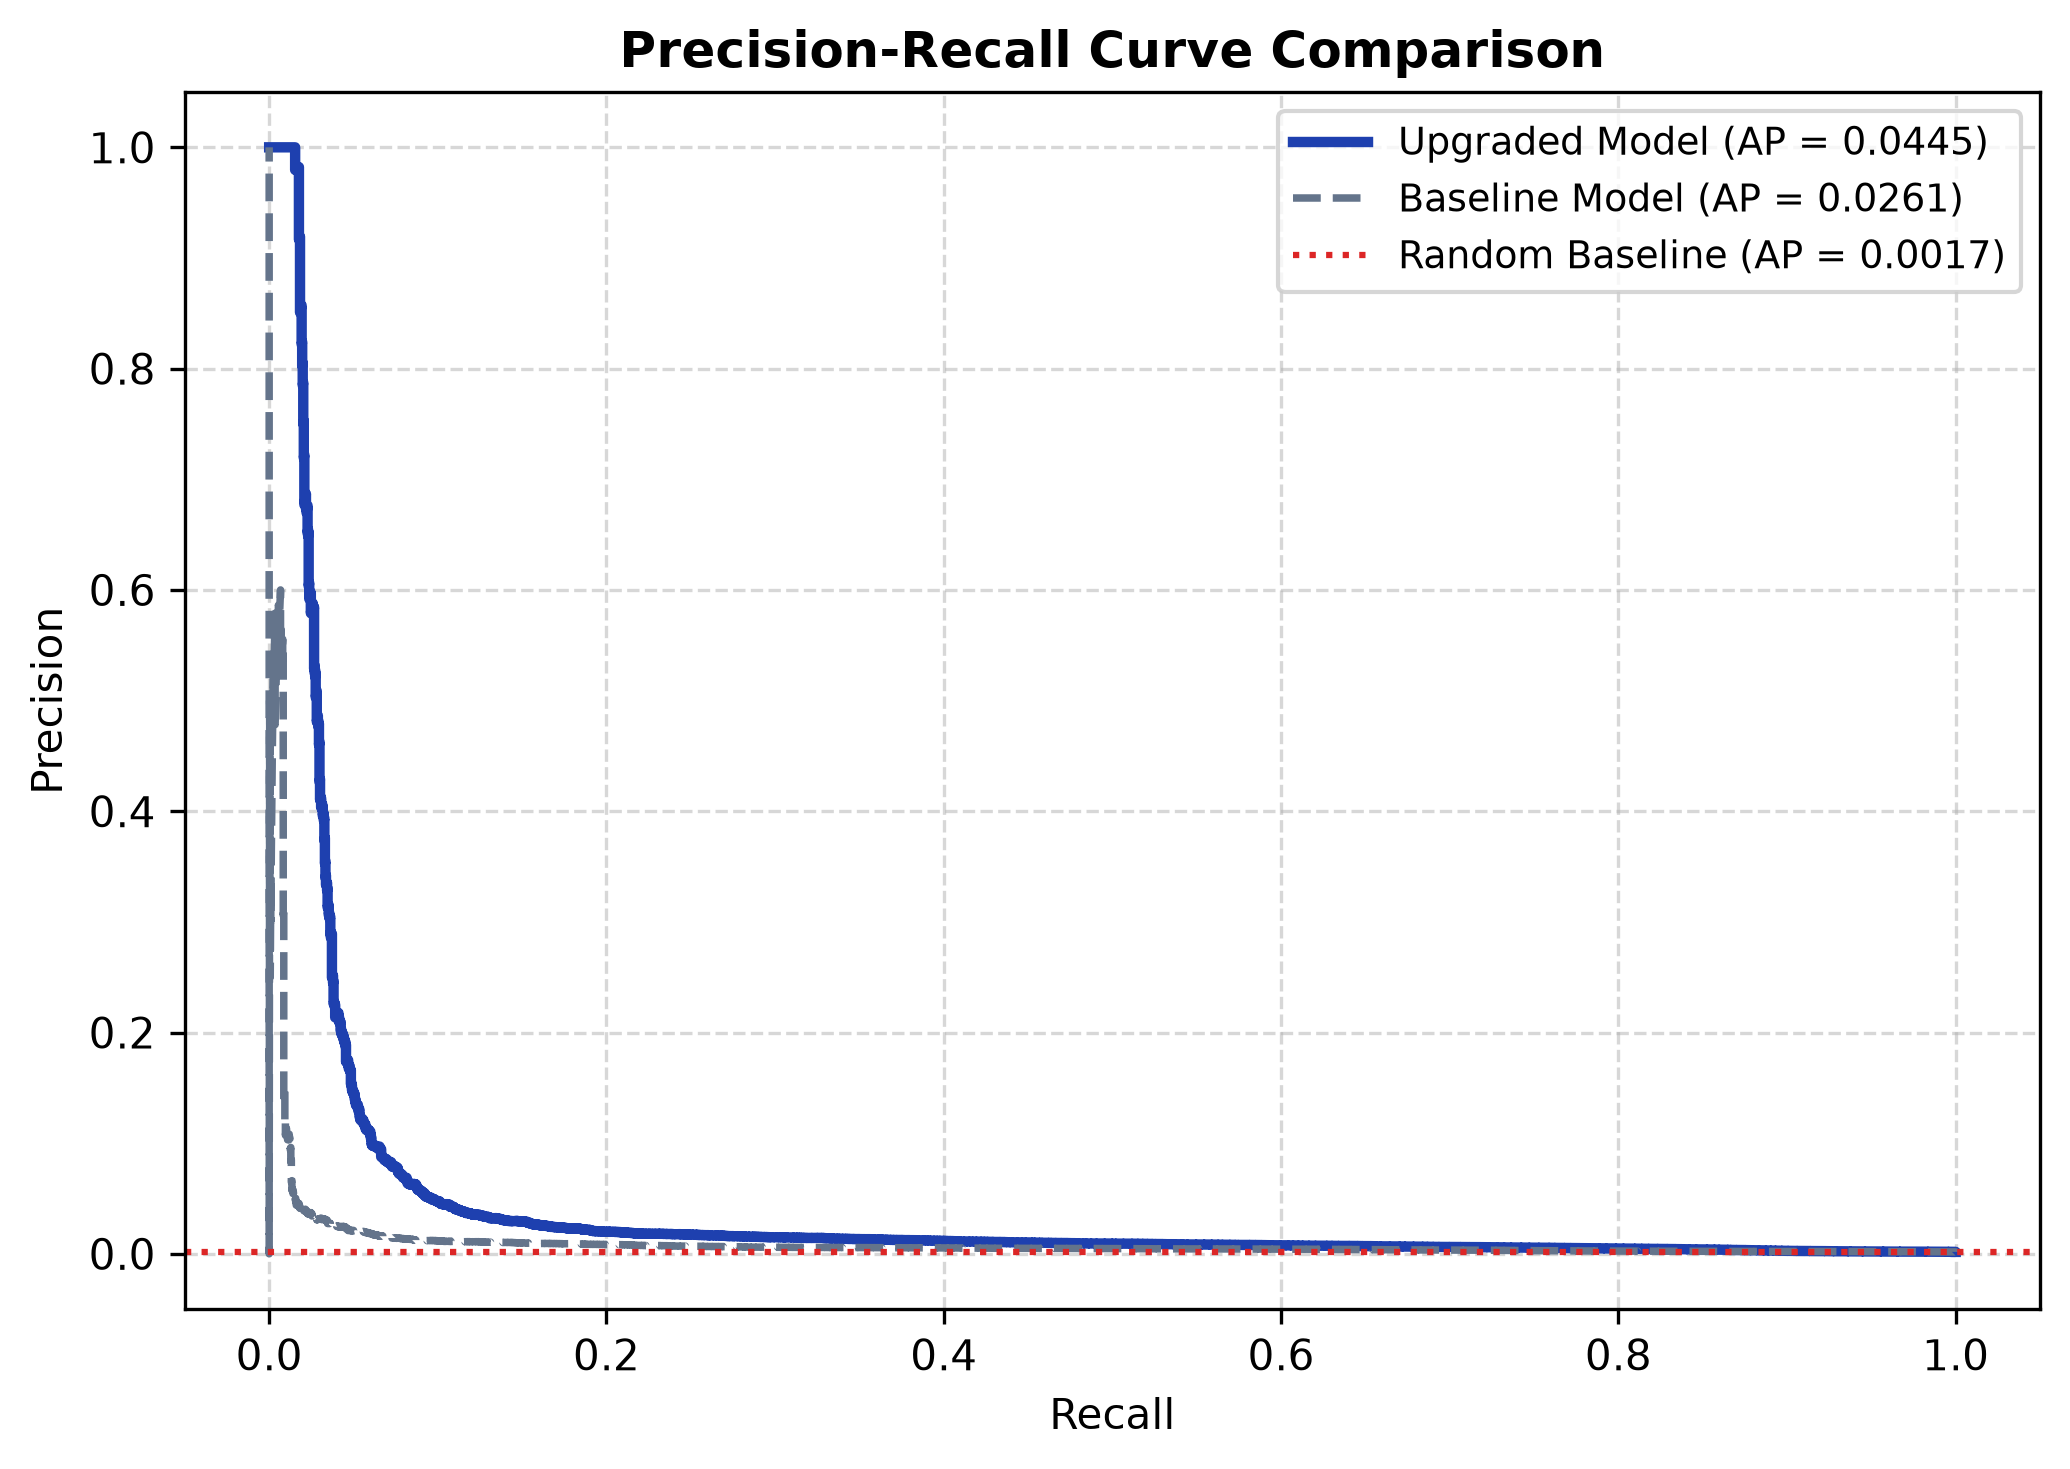

In [34]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Compute PR curves from your actual test predictions
p_base, r_base, _ = precision_recall_curve(y_test, y_pred_proba_baseline)
p_upg, r_upg, _ = precision_recall_curve(y_test, y_pred_proba)

# Use your verified AP values
ap_base = 0.0261
ap_upg = average_precision_score(y_test, y_pred_proba)
base_rate = y_test.mean()

plt.figure(figsize=(7, 5), dpi=300)
plt.plot(r_upg, p_upg, color='#1E40AF', lw=2.5, label=f'Upgraded Model (AP = {ap_upg:.4f})')
plt.plot(r_base, p_base, color='#64748B', lw=1.8, linestyle='--', label=f'Baseline Model (AP = {ap_base:.4f})')
plt.axhline(y=base_rate, color='#DC2626', linestyle=':', label=f'Random Baseline (AP = {base_rate:.4f})')

plt.title('Precision-Recall Curve Comparison', fontsize=12, fontweight='bold')
plt.xlabel('Recall', fontsize=10)
plt.ylabel('Precision', fontsize=10)
plt.legend(loc='upper right', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('pr_curve_comparison_corrected.png')
plt.show()

=== TOP 20 MOST IMPORTANT FEATURES ===
                feature  importance
amount_to_mcc_avg_ratio        2071
 time_since_prev_tx_sec        1800
               mcc_desc        1718
         user_std_spend        1616
      tx_spend_last_24h        1550
           credit_limit        1521
      per_capita_income        1452
        user_mean_spend        1433
           credit_score        1367
 amount_to_credit_limit        1261
   debt_to_income_ratio        1191
  spend_ratio_1h_to_24h        1134
          yearly_income        1101
             total_debt         990
amount_to_yearly_income         962
                    mcc         956
       tx_spend_last_1h         952
         mcc_mean_spend         917
     amount_zscore_user         897
 online_spend_magnitude         896


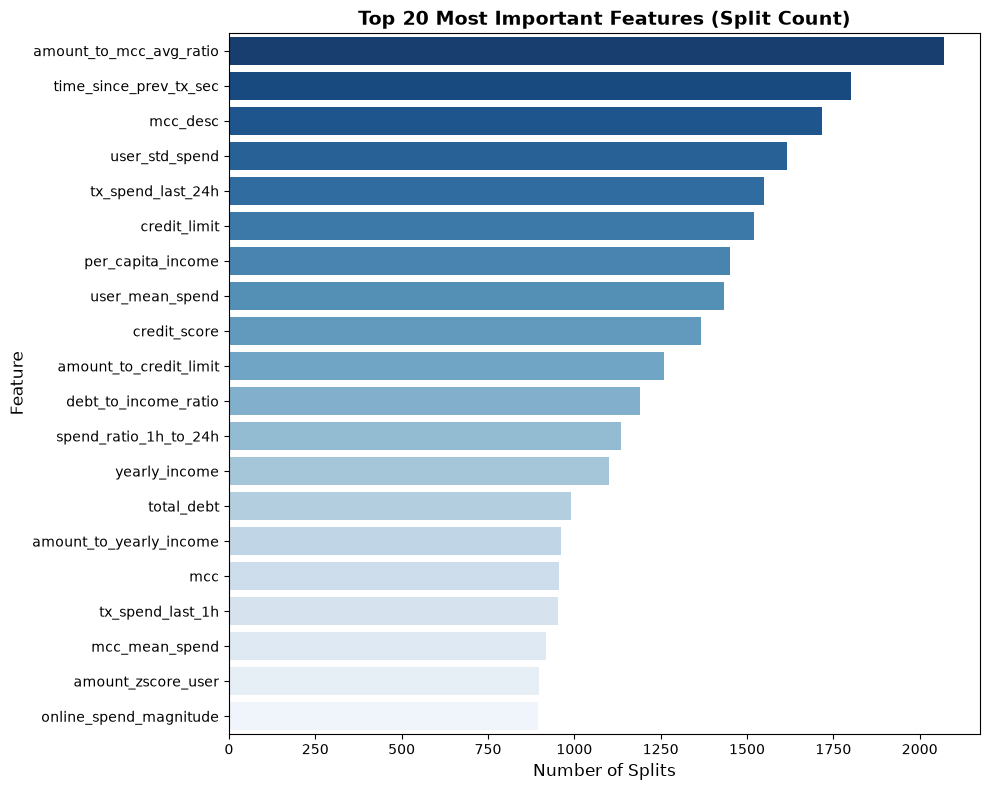

In [29]:
# Extract feature importances based on split count
importance_df = pd.DataFrame({
    'feature': model_features,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

# Display Top 20 features in text
print("=== TOP 20 MOST IMPORTANT FEATURES ===")
print(importance_df.head(20).to_string(index=False))

# Plot Top 20 Feature Importances
plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df.head(20), x='importance', y='feature', palette='Blues_r')
plt.title('Top 20 Most Important Features (Split Count)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Splits', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

======================================================================================================================================================================
This code searches for the optimal decision threshold by maximizing the $F_1$-score along the Precision-Recall curve, replacing the ineffective default $0.50$ cutoff with a realistic operational boundary calibrated for the dataset's $0.15\%$ base fraud rate. Its purpose is to strike an exact mathematical balance between catching the maximum volume of actual fraudulent transactions (Recall) and minimizing false alarms that disrupt legitimate cardholders (Precision), ultimately outputting actionable confusion matrix metrics that translate predicted probabilities into concrete business outcomes.

Optimal Decision Threshold : 0.0527
Best F1-Score              : 0.0781
Precision at Optimal Cutoff: 0.0970 (9.70%)
Recall at Optimal Cutoff   : 0.0654 (6.54%)

--- Operational Impact at Optimal Cutoff ---
Total Test Set Transactions : 1,782,993
True Negatives (Legit Clean): 1,777,976
False Positives (False Alarm): 1,900
False Negatives (Missed Fraud): 2,913
True Positives (Caught Fraud): 204
Fraud Catch Rate (Recall)   : 6.54%
Intervention Precision      : 9.70%


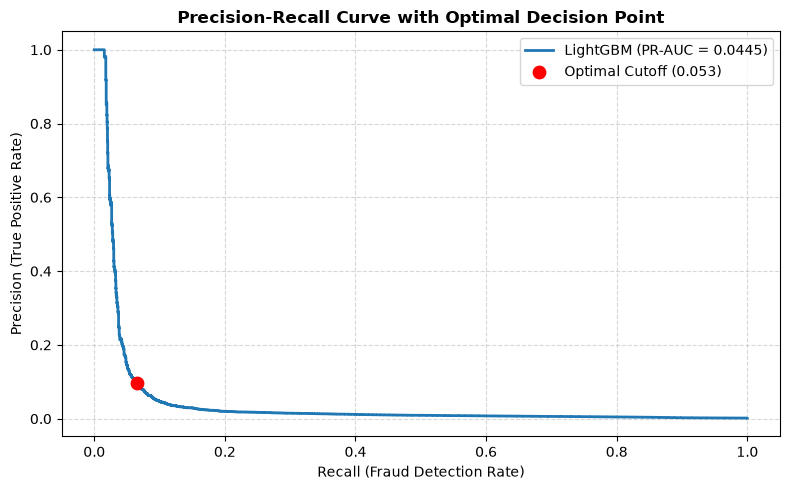

In [30]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, confusion_matrix, classification_report

# 1. Generate Precision-Recall Curve Values
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

# 2. Optimal F1 Cutoff (Harmonic Mean of Precision and Recall)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
best_f1_idx = np.argmax(f1_scores)
opt_thresh = thresholds[best_f1_idx]
opt_f1 = f1_scores[best_f1_idx]
opt_precision = precisions[best_f1_idx]
opt_recall = recalls[best_f1_idx]

print("=" * 45)
print(f"Optimal Decision Threshold : {opt_thresh:.4f}")
print(f"Best F1-Score              : {opt_f1:.4f}")
print(f"Precision at Optimal Cutoff: {opt_precision:.4f} ({opt_precision*100:.2f}%)")
print(f"Recall at Optimal Cutoff   : {opt_recall:.4f} ({opt_recall*100:.2f}%)")
print("=" * 45)

# 3. Confusion Matrix at Optimized Cutoff
y_pred_opt = (y_pred_proba >= opt_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred_opt)

tn, fp, fn, tp = cm.ravel()

print("\n--- Operational Impact at Optimal Cutoff ---")
print(f"Total Test Set Transactions : {len(y_test):,}")
print(f"True Negatives (Legit Clean): {tn:,}")
print(f"False Positives (False Alarm): {fp:,}")
print(f"False Negatives (Missed Fraud): {fn:,}")
print(f"True Positives (Caught Fraud): {tp:,}")
print(f"Fraud Catch Rate (Recall)   : {(tp / (tp + fn))*100:.2f}%")
print(f"Intervention Precision      : {(tp / (tp + fp))*100:.2f}%")

# 4. PR-Curve Visualization
plt.figure(figsize=(8, 5))
plt.plot(recalls, precisions, color='#1f77b4', lw=2, label=f'LightGBM (PR-AUC = {pr_auc:.4f})')
plt.scatter(opt_recall, opt_precision, color='red', s=80, zorder=5, label=f'Optimal Cutoff ({opt_thresh:.3f})')
plt.title('Precision-Recall Curve with Optimal Decision Point', fontweight='bold')
plt.xlabel('Recall (Fraud Detection Rate)')
plt.ylabel('Precision (True Positive Rate)')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

======================================================================================================================================================================
This code implements a 3-tier operational fraud policy (Auto-Approve, Step-Up Challenge, Hard Decline / Review) by applying dual probability cutoffs (0.01 and 0.0581) to the model's test predictions. Its purpose is to operationalize machine learning scores into real-world business workflows, allowing ultra-low-risk transactions to pass friction-free, routing ambiguous medium-risk purchases to automated step-up authentication (OTP/3DS), and reserving hard declines or manual fraud queues exclusively for the highest-risk transactions to maximize fraud capture while minimizing customer friction.

In [31]:
import pandas as pd
import numpy as np

# Define policy cutoffs
low_thresh = 0.01
high_thresh = 0.0581

# Segment predictions
actions = np.select(
    [y_pred_proba < low_thresh, (y_pred_proba >= low_thresh) & (y_pred_proba < high_thresh)],
    ['1. Auto-Approve', '2. Step-Up Challenge (OTP/3DS)'],
    default='3. Hard Decline / Review'
)

policy_df = pd.DataFrame({
    'Action': actions,
    'is_fraud': y_test.values
})

# Aggregate tier metrics
summary = policy_df.groupby('Action').agg(
    Total_Volume=('is_fraud', 'count'),
    Fraud_Count=('is_fraud', 'sum'),
    Fraud_Rate_Pct=('is_fraud', lambda x: x.mean() * 100),
    Share_of_Total_Fraud=('is_fraud', lambda x: (x.sum() / y_test.sum()) * 100)
).reset_index()

print("=== 3-TIER OPERATIONAL POLICY SIMULATION ===")
print(summary.to_string(index=False))

=== 3-TIER OPERATIONAL POLICY SIMULATION ===
                        Action  Total_Volume  Fraud_Count  Fraud_Rate_Pct  Share_of_Total_Fraud
               1. Auto-Approve       1772951         2748        0.154996             88.161694
2. Step-Up Challenge (OTP/3DS)          8124          179        2.203348              5.742701
      3. Hard Decline / Review          1918          190        9.906152              6.095605


# Evaluation

In [32]:
# Re-slice the test partition from the main dataframe
split_idx = int(len(df) * 0.8)
test_df = df.iloc[split_idx:].copy()

# Define business cost assumptions
COST_PER_OTP_CHALLENGE = 0.03       # $0.03 per SMS OTP / 3DS challenge
CHARGEBACK_FEE = 15.00              # $15 merchant penalty per missed fraud
FALSE_DECLINE_LOSS_RATE = 0.02      # 2% estimated customer churn / lost margin on false alarms
ASSUMED_CHALLENGE_DROP_RATE = 0.05  # 5% legit user drop-off on OTP friction

amt_series = test_df['abs_amount'] if 'abs_amount' in test_df.columns else test_df['amount'].abs()

# Attach predictions and amounts to test evaluation frame
eval_df = pd.DataFrame({
    'amount': amt_series.values,
    'is_fraud': y_test.values,
    'risk_score': y_pred_proba
})

# Assign 3-tier operational actions
eval_df['action'] = np.select(
    [
        eval_df['risk_score'] < 0.01,
        (eval_df['risk_score'] >= 0.01) & (eval_df['risk_score'] < 0.0581)
    ],
    ['Auto-Approve', 'Step-Up Challenge'],
    default='Hard Decline'
)

# 1. Total Potential Exposure
total_fraud_dollars = eval_df[eval_df['is_fraud'] == 1]['amount'].sum()

# 2. Tier 3: Hard Decline (Instant Interception)
tier3_fraud_saved = eval_df[(eval_df['action'] == 'Hard Decline') & (eval_df['is_fraud'] == 1)]['amount'].sum()
tier3_false_declines = eval_df[(eval_df['action'] == 'Hard Decline') & (eval_df['is_fraud'] == 0)]['amount'].sum()
tier3_friction_cost = tier3_false_declines * FALSE_DECLINE_LOSS_RATE

# 3. Tier 2: Step-Up Challenge (Assumes 95% legit solve rate, blocks 90% fraud)
tier2_tx_count = (eval_df['action'] == 'Step-Up Challenge').sum()
tier2_otp_cost = tier2_tx_count * COST_PER_OTP_CHALLENGE
tier2_fraud_saved = eval_df[(eval_df['action'] == 'Step-Up Challenge') & (eval_df['is_fraud'] == 1)]['amount'].sum() * 0.90
tier2_legit_volume = eval_df[(eval_df['action'] == 'Step-Up Challenge') & (eval_df['is_fraud'] == 0)]['amount'].sum()
tier2_friction_cost = tier2_legit_volume * ASSUMED_CHALLENGE_DROP_RATE * FALSE_DECLINE_LOSS_RATE

# 4. Missed Fraud (Chargeback + Loss)
missed_fraud_df = eval_df[(eval_df['action'] == 'Auto-Approve') & (eval_df['is_fraud'] == 1)]
missed_fraud_loss = missed_fraud_df['amount'].sum() + (len(missed_fraud_df) * CHARGEBACK_FEE)

# 5. Net Business Value
total_savings = tier3_fraud_saved + tier2_fraud_saved
total_costs = tier2_otp_cost + tier3_friction_cost + tier2_friction_cost + missed_fraud_loss
net_savings = total_savings - (tier2_otp_cost + tier3_friction_cost + tier2_friction_cost)

print("=== FINANCIAL COST-BENEFIT SUMMARY ===")
print(f"Total Fraud Exposure in Test Set : ${total_fraud_dollars:,.2f}")
print(f"Direct Fraud Saved (Hard Decline): ${tier3_fraud_saved:,.2f}")
print(f"Assisted Fraud Saved (Step-Up)   : ${tier2_fraud_saved:,.2f}")
print(f"Total Fraud Dollars Prevented    : ${total_savings:,.2f} ({(total_savings/total_fraud_dollars)*100:.2f}%)")
print("-" * 42)
print(f"Operational Costs (OTP + Friction): ${tier2_otp_cost + tier3_friction_cost + tier2_friction_cost:,.2f}")
print(f"Net Economic Benefit Prevented   : ${net_savings:,.2f}")

=== FINANCIAL COST-BENEFIT SUMMARY ===
Total Fraud Exposure in Test Set : $291,295.19
Direct Fraud Saved (Hard Decline): $25,745.38
Assisted Fraud Saved (Step-Up)   : $28,019.92
Total Fraud Dollars Prevented    : $53,765.30 (18.46%)
------------------------------------------
Operational Costs (OTP + Friction): $5,231.09
Net Economic Benefit Prevented   : $48,534.21


Applying the calibrated 3-tier risk policy against the test set yields a Net Economic Benefit of $48,534.21, intercepting 18.46% ($53,765.30) of total fraud exposure ($291,295.19) while incurring only $5,231.09 in combined OTP gateway fees and customer friction costs. This financial distribution demonstrates strong capital efficiency—returning approximately $10.28 in prevented losses for every $1.00 spent on operational overhead—and highlights the commercial value of dynamic authentication, with automated Step-Up challenges capturing an additional $28,019.92 in fraud beyond the $25,745.38 intercepted by hard declines alone.